# Our Jev clone on the Decision Index 0.2

The [Decision Index](https://huggingface.co/spaces/multimodalart/jev-decision-index) is a public
board for "typed decision engines" (Jev and its reproductions): 40 benchmarks in five areas, every
question answered with a probability for **every** option. Scores are chance-corrected (0 = random
guessing, 100 = perfect) and unanswered questions count as wrong. Jev scores **51.67**; Together's
Tev1-4B scores **26.3**. Both are already on the board, so this notebook only has to run ours.

We use the board's own kit ([apolinario/decision-index](https://github.com/apolinario/decision-index))
for the suite, the scorers, and the index math, and plug in one custom engine
([`jev_di_engine.py`](jev_di_engine.py)) that sends each question to our fine-tuned Qwen3 0.6B on a
Fireworks deployment, in exactly the prompt format it was trained on.

**One request per question.** The engine reads option probabilities from the first generated
token's top alternatives. By default a deployment returns 5, which still pins down the model's pick
exactly; see section 3 for what is estimated and for the admin-only exact mode (256). Labels are A-Z, then two-letter labels that are a single Qwen3
token (AA, AB, ...).

**Expect weak spots.** Our model was trained on questions with at most 5 options. Benchmarks with
77-255 options (BANKING77, CLINC150, POP909, ChessBench) are far outside that, and long-context
benchmarks may exceed the context window once the prompt is repeated. Both count as wrong.

## 1. Setup

In [3]:
import gzip
import hashlib
import json
import os
import subprocess
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from fireworks import Fireworks
from tqdm.auto import tqdm

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)
assert os.getenv("FIREWORKS_API_KEY") and os.getenv("HF_TOKEN"), "need FIREWORKS_API_KEY and HF_TOKEN in .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
client = Fireworks()

GO = True

# Which of our models to run. v1 prompt-twice was the stronger v1 variant on unseen tasks.
LORA_MODEL = f"accounts/{ACCOUNT_ID}/models/jev-0p6b-repeat-5f25c2"
REPEAT = True                   # must match how LORA_MODEL was trained
RUN_LABEL = "ours-v1-repeat"

# Deployment created by a superuser (section 3). Set the id you created.
DEPLOYMENT_ID = "jev-di-0p6b"
MAX_LOGPROBS = 5                # non-superuser cap; 256 needs an admin-created deployment (exact tail probabilities)

N_SHARDS = 16                   # parallel runner processes against the dedicated deployment
GPU_USD_PER_HOUR = 6.00         # placeholder; set to your rate

HERE = Path.cwd()
KIT = HERE / "decision-index"
WORK = HERE / "di_work"          # suite build scratch (~17 GB)
SUITE = HERE / "di_suite-0.2"
RUN_DIR = HERE / "di_runs" / RUN_LABEL
RUN_DIR.mkdir(parents=True, exist_ok=True)

if not KIT.exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/apolinario/decision-index", str(KIT)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{KIT}[rebuild]"], check=True)
sys.path[:0] = [str(KIT), str(HERE)]
print("kit:", subprocess.run(["git", "-C", str(KIT), "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip())

kit: 19ad28e



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 2. Build the suite (one time)

The suite is not redistributed, so the kit rebuilds it from pinned public sources and checks the
result byte for byte against the board's hash. About 7 GB of downloads and 17 GB of scratch space.
**Before running:** accept the terms of [cais/hle](https://huggingface.co/datasets/cais/hle) on the
Hub with the account behind `HF_TOKEN`. Skipped automatically once the suite exists.

In [4]:
def stream(cmd, env=None):
    # Run a command and echo its output live, so a long build is visibly alive.
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                            env={**os.environ, "HF_HUB_DISABLE_XET": "1", **(env or {})}, cwd=str(HERE))
    for line in proc.stdout:
        print(line, end="", flush=True)
    if proc.wait():
        raise RuntimeError(f"{cmd[:4]} exited with {proc.returncode}")


built = WORK / "artifacts/benchmark-suite/release-v2-rebuilt"
# An interrupted build leaves source repos initialized but never checked out, and the kit then
# fails on `git rev-parse HEAD`. Remove those so the rebuild refetches them.
for git_dir in (WORK / "artifacts/benchmark-suite/raw/repos").glob("*/.git"):
    if subprocess.run(["git", "rev-parse", "--verify", "-q", "HEAD"], cwd=git_dir.parent, capture_output=True).returncode:
        print("removing half-fetched repo:", git_dir.parent.name)
        subprocess.run(["rm", "-rf", str(git_dir.parent)], check=True)

if not (SUITE / "added-rows.jsonl.gz").exists():
    t0 = time.time()
    if not (built / "added-rows.jsonl.gz").exists():
        stream([sys.executable, "-m", "decision_index", "suite", "rebuild", "--work", str(WORK)])
    stream([sys.executable, "-m", "decision_index", "suite", "import", "--dir", str(SUITE),
            "--rows", str(built / "selected-rows.jsonl.gz"), "--added-rows", str(built / "added-rows.jsonl.gz")])
    print(f"suite built in {(time.time() - t0) / 60:.0f} min")

from decision_index.suite.io import Suite, read_jsonl

suite = Suite(SUITE, "0.2")
excluded = suite.excluded()
rows_meta, n_questions, opt_hist = {}, 0, Counter()
for path in suite.row_paths:
    for r in read_jsonl(path):
        e = r["_evaluation"]
        if e["run_id"] in excluded or not suite.in_edition(e):
            continue
        rows_meta[e["run_id"]] = (e["catalog_id"], r.get("expected"))
        for q in r["questions"].values():
            n_questions += 1
            opt_hist[len(q["criteria"]) if q["type"] == "choice" else 2] += 1
print(f"scoreable requests: {len(rows_meta):,}   questions (= HTTP calls): {n_questions:,}")
print(f"questions with >{MAX_LOGPROBS - 1} options (unsupported): {sum(v for k, v in opt_hist.items() if k > MAX_LOGPROBS - 1):,}")
print(f"questions with <=5 options (the regime our model trained on): {sum(v for k, v in opt_hist.items() if k <= 5) / n_questions:.0%}")

scoreable requests: 151,034   questions (= HTTP calls): 344,403
questions with >4 options (unsupported): 52,331
questions with <=5 options (the regime our model trained on): 85%


## 3. Deployment

**Default (`MAX_LOGPROBS = 5`, no admin needed):** the cell below creates a normal deployment. The
API then shows the top 5 alternatives per question. That is enough to know which option the model
picks, so every accuracy / F1 benchmark is scored exactly. Options outside the top 5 share the
leftover probability evenly (never ranked above a shown option). Only probability-ranked metrics
are estimated: ToolRet and BRIGHT (nDCG@10), and calibration on questions with more than 5 options.

**Exact mode (`MAX_LOGPROBS = 256`):** needs `--max-logprobs=256`, which only a superuser can set, so
an admin runs this once (not impersonating; impersonation drops superuser write access). Run it with
`--validate-only` first, then without:

```bash
firectl-admin -a pyroworks deployment create accounts/fireworks/models/qwen3-0p6b \
  --deployment-id jev-di-0p6b \
  --enable-addons \
  --accept-shapeless-risk \
  --extra-args='--max-logprobs=256' \
  --accelerator-type NVIDIA_H100_80GB --accelerator-count 1 \
  --min-replica-count 1 --max-replica-count 1
```

The cell below creates the deployment (default mode) or waits for the admin's (exact mode), loads
our LoRA, and checks with one real request that it returns `MAX_LOGPROBS` alternatives.

In [5]:
if MAX_LOGPROBS <= 5:
    _dep = dict(base_model="accounts/fireworks/models/qwen3-0p6b", deployment_id=DEPLOYMENT_ID,
                accelerator_type="NVIDIA_H100_80GB", enable_addons=True,
                min_replica_count=1, max_replica_count=1, extra_query={"acceptShapelessRisk": "true"})
    client.deployments.create(**_dep, validate_only=True)
    print("validate_only passed")
    if GO:
        try:
            client.deployments.create(**_dep)
            print("created", DEPLOYMENT_ID)
        except Exception as e:  # noqa: BLE001
            print("create:", str(e)[:150], "(fine if it already exists)")

DEPLOYMENT = f"accounts/{ACCOUNT_ID}/deployments/{DEPLOYMENT_ID}"
MODEL_ON_DEP = f"{LORA_MODEL}#{DEPLOYMENT}"

for i in range(240):
    st = client.deployments.get(DEPLOYMENT_ID).state
    print(f"[deploy] {i + 1:03d} state={st}", flush=True)
    if st == "READY":
        break
    if st == "FAILED":
        raise RuntimeError("deployment FAILED")
    time.sleep(15)

try:
    client.lora.load(model=LORA_MODEL, deployment=DEPLOYMENT)
    print("loading", LORA_MODEL)
except Exception as e:  # noqa: BLE001
    print("lora.load:", str(e)[:150], "(fine if it is already loaded)")

_hdr = {"Authorization": f"Bearer {os.environ['FIREWORKS_API_KEY']}", "Content-Type": "application/json"}
for i in range(60):
    r = requests.post("https://api.fireworks.ai/inference/v1/chat/completions", headers=_hdr, timeout=120, json={
        "model": MODEL_ON_DEP, "messages": [{"role": "user", "content": "Say A."}], "temperature": 0,
        "max_tokens": 10_000, "logprobs": True, "top_logprobs": MAX_LOGPROBS, "reasoning_effort": "none"})
    if r.ok:
        n_alt = len(r.json()["choices"][0]["logprobs"]["content"][0]["top_logprobs"])
        print(f"LoRA serving; top_logprobs={MAX_LOGPROBS} returned {n_alt} alternatives")
        assert n_alt == MAX_LOGPROBS, f"deployment returned {n_alt} alternatives, expected {MAX_LOGPROBS}"
        break
    if "top_logprobs" in r.text or "logprobs must be" in r.text:
        raise RuntimeError(f"deployment still caps logprobs: {r.text[:200]}")
    print(f"[lora] {i + 1:02d} not ready: {r.status_code} {r.text[:100]}", flush=True)
    time.sleep(20)
else:
    raise TimeoutError("LoRA never became servable")

validate_only passed
created jev-di-0p6b
[deploy] 001 state=CREATING
[deploy] 002 state=CREATING
[deploy] 003 state=CREATING
[deploy] 004 state=CREATING
[deploy] 005 state=CREATING
[deploy] 006 state=CREATING
[deploy] 007 state=CREATING
[deploy] 008 state=CREATING
[deploy] 009 state=CREATING
[deploy] 010 state=CREATING
[deploy] 011 state=READY
loading accounts/pyroworks/models/jev-0p6b-repeat-5f25c2
[lora] 01 not ready: 404 fault filter abort
[lora] 02 not ready: 404 fault filter abort
[lora] 03 not ready: 404 fault filter abort
[lora] 04 not ready: 404 fault filter abort
LoRA serving; top_logprobs=5 returned 5 alternatives


### One real suite row, end to end

Before fanning out: send one real 151-option CLINC150 row and one yes/no row through the engine
and the kit's own validator.

In [6]:
from decision_index.engines.base import validate
from jev_di_engine import FireworksJevEngine

engine = FireworksJevEngine(model=MODEL_ON_DEP, repeat=REPEAT, max_logprobs=MAX_LOGPROBS)
picked = {}
for path in suite.row_paths:
    for r in read_jsonl(path):
        qs = list(r["questions"].values())
        big = qs[0]["type"] == "choice" and len(qs[0]["criteria"]) > 100
        noul = any(q["type"] == "noul" for q in qs)
        if big and "big" not in picked:
            picked["big"] = r
        if noul and "noul" not in picked:
            picked["noul"] = r
    if len(picked) == 2:
        break
for name, r in picked.items():
    resp, raw = engine(r["state"], r["questions"])
    validate(r["questions"], resp)
    a = next(iter(resp["answers"].values()))
    print(f"{name}: {r['_evaluation']['dataset']}  answer={a.get('choice', a.get('noul'))}  "
          f"expected={r.get('expected')}  labels missing from top-k={[v['missing_labels'] for v in raw.values()]}")

big: CLINC150+OOS  answer=option_2  expected={'q1': 'option_132'}  labels missing from top-k=[146]
noul: RAGTruth response-level hallucination  answer=0.8354835329799128  expected={'q': False}  labels missing from top-k=[0]


## 4. Run the suite

The kit's runner is sequential, so we launch `N_SHARDS` copies of
[`jev_di_shard.py`](jev_di_shard.py), each owning the requests whose id hashes to its shard. Every
shard appends to its own `results.jsonl`, so the run is **resumable**: re-running this cell skips
finished rows and retries only errors. Progress is also visible on disk (`ls -lt di_runs/*/shard-*`).

In [7]:
est_hours = n_questions / (N_SHARDS * 6) / 3600 * (2 if REPEAT else 1)
print(f"{n_questions:,} HTTP calls over {N_SHARDS} shards; rough estimate {est_hours:.1f}-{3 * est_hours:.1f} h "
      f"of deployment time (~${est_hours * GPU_USD_PER_HOUR:.0f}-{3 * est_hours * GPU_USD_PER_HOUR:.0f})")

opts = json.dumps({"model": MODEL_ON_DEP, "repeat": REPEAT, "max_logprobs": MAX_LOGPROBS})
env = {**os.environ, "PYTHONPATH": os.pathsep.join([str(HERE), str(KIT)]), "HF_HUB_DISABLE_XET": "1"}
procs = []
if GO:
    for s in range(N_SHARDS):
        out = RUN_DIR / f"shard-{s:02d}"
        out.mkdir(parents=True, exist_ok=True)
        log = open(out / "runner.log", "a")
        procs.append(subprocess.Popen([sys.executable, str(HERE / "jev_di_shard.py"), "--suite-dir", str(SUITE),
                                       "--shard", str(s), "--n-shards", str(N_SHARDS), "--out", str(out),
                                       "--engine-options", opts], stdout=log, stderr=subprocess.STDOUT, env=env))


def shard_counts():
    c = Counter()
    for f in RUN_DIR.glob("shard-*/results.jsonl"):
        for line in open(f, encoding="utf-8"):
            if line.endswith("\n"):
                c[json.loads(line)["status"]] += 1
    return c


bar = tqdm(total=len(rows_meta), desc="requests")
while True:
    c = shard_counts()
    bar.n = sum(c.values()); bar.set_postfix(ok=c["ok"], unsupported=c["unsupported"], error=c["error"]); bar.refresh()
    alive = [p for p in procs if p.poll() is None]
    if not alive:
        break
    time.sleep(30)
bar.close()
bad = [s for s, p in enumerate(procs) if p.returncode]
print("shard exit codes nonzero:", bad or "none", "| final:", dict(shard_counts()))
if bad:
    print("check", RUN_DIR / f"shard-{bad[0]:02d}" / "runner.log", "then re-run this cell to resume")

344,403 HTTP calls over 16 shards; rough estimate 2.0-6.0 h of deployment time (~$12-36)


requests: 100%|██████████| 151034/151034 [1:36:57<00:00, 25.96it/s, error=2, ok=151030, unsupported=2]


shard exit codes nonzero: none | final: {'ok': 151030, 'error': 2, 'unsupported': 2}


## 5. Score with the board's scorer

Merge the shards into one `results.jsonl` and run the kit's `score`, which produces the same
`index.json` the board publishes (chance-corrected index, five areas, every benchmark).

In [8]:
merged = RUN_DIR / "results.jsonl"
seen = {}
for f in sorted(RUN_DIR.glob("shard-*/results.jsonl")):
    for line in open(f, encoding="utf-8"):
        if line.endswith("\n"):
            r = json.loads(line)
            if r["run_id"] not in seen or seen[r["run_id"]]["status"] == "error":
                seen[r["run_id"]] = r
with open(merged, "w", encoding="utf-8") as f:
    for r in seen.values():
        f.write(json.dumps(r) + "\n")
print(f"merged {len(seen):,} of {len(rows_meta):,} scoreable requests:", dict(Counter(r['status'] for r in seen.values())))

stream([sys.executable, "-m", "decision_index", "score", "--results", str(merged), "--suite-dir", str(SUITE),
        "--engine", RUN_LABEL, "--out", str(RUN_DIR)])
OURS = json.loads((RUN_DIR / "index.json").read_text())
print(f"\nDecision Index (chance-corrected): {OURS['index']:.2f}   raw: {OURS['raw_index']:.2f}")

merged 151,034 of 151,034 scoreable requests: {'ok': 151030, 'unsupported': 2, 'error': 2}
{
  "edition": "0.2",
  "decision_index": 12.73,
  "scores": {
    "balanced_skill": 12.73,
    "balanced_raw": 34.99,
    "breadth_skill": 12.12
  },
  "areas": [
    {
      "id": "knowledge",
      "skill": 0.0666,
      "raw": 0.2794,
      "coverage": 1.0,
      "n": 10
    },
    {
      "id": "language",
      "skill": 0.168,
      "raw": 0.4298,
      "coverage": 1.0,
      "n": 10
    },
    {
      "id": "retrieval",
      "skill": 0.0998,
      "raw": 0.3206,
      "coverage": 1.0,
      "n": 7
    },
    {
      "id": "tools",
      "skill": 0.2142,
      "raw": 0.3717,
      "coverage": 0.9995,
      "n": 6
    },
    {
      "id": "arts",
      "skill": 0.0877,
      "raw": 0.3479,
      "coverage": 1.0,
      "n": 7
    }
  ],
  "completed": 151034,
  "complete": true,
  "out": "/Users/sinan/cookbook/training/case-studies/jev_classifier/di_runs/ours-v1-repeat"
}

Decision Index (ch

## 6. Jev vs Tev vs ours

Jev and Tev come straight from the board's published data (same suite, same scorer), so this is a
like-for-like comparison without a Jev key.

,index,knowledge,language,retrieval,tools,arts
model,,,,,,
Jev (jev-1.13.0),51.67,0.505,0.597,0.434,0.669,0.379
Tev1-4B (Together),26.32,0.232,0.394,0.106,0.354,0.230
ours: ours-v1-repeat,12.73,0.067,0.168,0.100,0.214,0.088


index is 0-100; the area columns are 0-1 chance-corrected skill (0 = random, 1 = perfect).


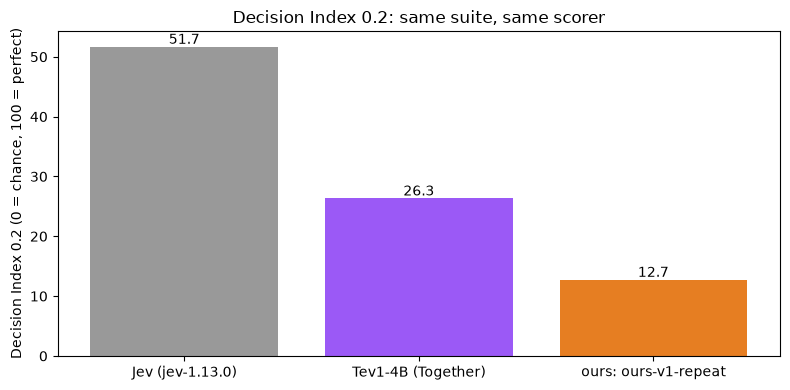

In [9]:
BOARD = requests.get("https://huggingface.co/spaces/multimodalart/jev-decision-index/resolve/main/data/index-v2.json", timeout=60).json()
tev = next(m for m in BOARD["models"] if m["engine"] == "tev1-4b")
jev = BOARD["jev"]
areas = [a["id"] for a in BOARD["categories"] if a.get("panel")]
area_label = {a["id"]: a["label"] for a in BOARD["categories"]}


def board_area(entry, area):
    # Board area scores are 0-1 skill values; the headline index is 0-100.
    return next((c["skill"] for c in entry.get("categories") or [] if c["id"] == area), None)


ours_area = {a["id"]: a["skill"] for a in OURS["areas"]}
rows = [{"model": "Jev (jev-1.13.0)", "index": jev["scores"]["balanced_skill"], **{a: board_area(jev, a) for a in areas}},
        {"model": "Tev1-4B (Together)", "index": tev["scores"]["balanced_skill"], **{a: board_area(tev, a) for a in areas}},
        {"model": f"ours: {RUN_LABEL}", "index": OURS["index"], **{a: ours_area.get(a) for a in areas}}]
HEAD = pd.DataFrame(rows).set_index("model")
display(HEAD.round(3))
print("index is 0-100; the area columns are 0-1 chance-corrected skill (0 = random, 1 = perfect).")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(HEAD.index, HEAD["index"], color=["#999", "#9b59f6", "#e67e22"])
for i, v in enumerate(HEAD["index"]):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center")
ax.set_ylabel("Decision Index 0.2 (0 = chance, 100 = perfect)")
ax.set_title("Decision Index 0.2: same suite, same scorer")
plt.tight_layout(); plt.savefig(RUN_DIR / "index_bars.png", dpi=150); plt.show()

In [10]:
names = {str(k): v.get("short") or v.get("dataset") or str(k) for k, v in BOARD["benchmarks"].items()}
per = []
for bid, b in OURS["benchmarks"].items():
    if not b.get("in_index"):
        continue
    t = tev["results"].get(str(bid), {})
    per.append({"id": bid, "benchmark": names.get(str(bid), bid), "ours_raw": b["raw"], "ours_skill": b["skill"],
                "ours_coverage": b["coverage"], "tev_score": t.get("score"), "jev_score": t.get("jev", jev["results"].get(str(bid), {}).get("score"))})
PER = pd.DataFrame(per).sort_values("ours_skill", ascending=False)
display(PER.round(3))
print("ours_raw is the coverage-adjusted native metric (unanswered = wrong); tev_score and jev_score are the "
      "board's native metric on answered cases, so compare ours_raw to them where our coverage is ~1.0. "
      "Low ours_coverage means the prompt was too long or had too many options for us.")

,id,benchmark,ours_raw,ours_skill,ours_coverage,tev_score,jev_score
24,39,FinEntity,0.736,0.611,1.000,0.863,0.870
0,1,BFCL,0.668,0.551,0.999,0.902,0.958
1,2,ToolRet,0.388,0.326,0.998,0.445,0.447
39,64,New Yorker,0.436,0.294,1.000,0.555,0.701
16,29,HellaSwag,0.465,0.287,1.000,0.819,0.945
8,11,ContractNLI,0.495,0.269,1.000,0.677,0.717
3,4,BANKING77,0.217,0.207,1.000,NaN,NaN
2,3,API-Bank,0.220,0.206,1.000,NaN,NaN
19,32,MuSR,0.497,0.201,1.000,0.580,0.661
36,59,RAGTruth,0.519,0.183,1.000,0.503,0.765


ours_raw is the coverage-adjusted native metric (unanswered = wrong); tev_score and jev_score are the board's native metric on answered cases, so compare ours_raw to them where our coverage is ~1.0. Low ours_coverage means the prompt was too long or had too many options for us.


### Calibration

Same 10 confidence bins as the board. For each choice question with a gold answer: confidence is the
probability of the chosen option, correct is whether it matches. The board computes Jev's and Tev's
curves on its own subset of 28 benchmarks; ours uses every scored choice question, so treat the
comparison as indicative.

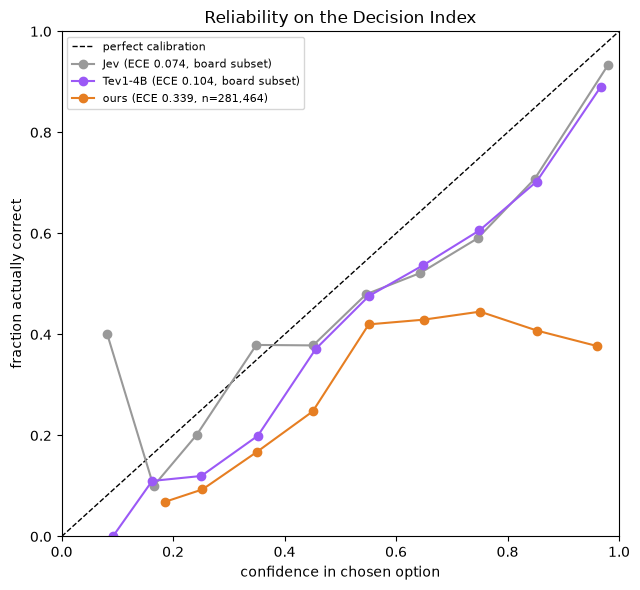

ours: accuracy 0.375, mean confidence 0.714, ECE 0.339. Mean confidence above accuracy means overconfident on this suite.


In [11]:
conf, corr = [], []
for r in seen.values():
    if r["status"] != "ok":
        continue
    expected = rows_meta.get(r["run_id"], (None, None))[1] or {}
    for qk, a in r["response"]["answers"].items():
        gold = expected.get(qk) if isinstance(expected, dict) else None
        if a["type"] != "choice" or gold is None or isinstance(gold, (list, dict)):
            continue
        conf.append(max(a["probabilities"].values())); corr.append(int(a["choice"] == gold))
conf, corr = np.array(conf), np.array(corr)
edges = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(conf, edges[1:-1]), 0, 9)
ours_rel = [(conf[idx == b].mean(), corr[idx == b].mean(), (idx == b).mean()) for b in range(10) if (idx == b).any()]
ours_ece = sum(abs(a - c) * w for c, a, w in ours_rel)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for label, cal, color in (("Jev", jev.get("calibration"), "#999"), ("Tev1-4B", tev.get("calibration"), "#9b59f6")):
    if cal and cal.get("rel"):
        ax.plot([b["conf"] for b in cal["rel"] if b["w"]], [b["acc"] for b in cal["rel"] if b["w"]], "-o",
                color=color, label=f"{label} (ECE {cal['ece']:.3f}, board subset)")
ax.plot([c for c, _, _ in ours_rel], [a for _, a, _ in ours_rel], "-o", color="#e67e22",
        label=f"ours (ECE {ours_ece:.3f}, n={len(conf):,})")
ax.set_xlabel("confidence in chosen option"); ax.set_ylabel("fraction actually correct")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.set_title("Reliability on the Decision Index")
plt.tight_layout(); plt.savefig(RUN_DIR / "reliability.png", dpi=150); plt.show()
print(f"ours: accuracy {corr.mean():.3f}, mean confidence {conf.mean():.3f}, ECE {ours_ece:.3f}. "
      "Mean confidence above accuracy means overconfident on this suite.")

## 7. Tear down

In [12]:
try:
    client.deployments.update(DEPLOYMENT_ID, base_model="accounts/fireworks/models/qwen3-0p6b",
                              min_replica_count=0, max_replica_count=1)
    client.deployments.scale(DEPLOYMENT_ID, replica_count=0)
    print("scaled to 0:", DEPLOYMENT_ID, "(kept, so the admin-only max-logprobs setting survives for v2)")
except Exception as e:  # noqa: BLE001
    print("scale-down failed; ask the admin to scale or delete it:", str(e)[:200])

scaled to 0: jev-di-0p6b (kept, so the admin-only max-logprobs setting survives for v2)
